In [261]:
import pandas as pd 
import xarray as xr
import numpy as np 
import matplotlib.pyplot as plt 
from  Divergencecals import *

## Sverdrup Calcuations based on ERA 5 winds for 3 degree box around palmyra 

- Curently am calculating this but do not know what the boundry conditions should be... 

In [262]:
wind = xr.open_dataset(r'Data\ERA5_10m_winds.nc')
wind = wind.sortby('lat')
windm = wind.sel(time = slice('2022-01-01', '2025-01-01'))
windm = windm.mean(dim='time')

In [301]:
def Calc_sverdrup(windm):
    from scipy.integrate import cumulative_trapezoid
    rho = 1.3 ## density of Air [kg/m^3]
    C_d = 1.25e-3  # wind stress coefient
    rho_w = 1025 # [kg/m^3]
    R = 6371e3 #radius 
    omega = 7.29e-5 # [1/s]

    dlat = np.deg2rad(np.gradient(windm.lat.values))
    dlon = np.deg2rad(np.gradient(windm.lon.values))
    print(f"Lat: {len(dlat)} \nlon: {len(dlon )}")
    dy = R * dlat
    dx = R * dlon
    dlat_lon = np.cos(np.deg2rad(windm.lat.values)) ## how dlat varies with latitude 

    #Generate grid of dlat and dlon 
    dy_grid = np.repeat(dy.reshape(-1,1),len(dx), axis = 1)
    dx_grid = (np.repeat(dx.reshape(1,-1),len(dy), axis = 0).T *dlat_lon).T #transpose to match 
    print(f'dy gird {dy_grid.shape}')
    print(f'dy gird {dx_grid.shape}')

    U_w = np.sqrt(windm.uo**2 + windm.vo**2) ## Chat GPT says to Tau = rho * C_d * U * |U| ???? 
    windm['tau_u'] = rho*C_d*windm.uo*U_w # [N/m^2]
    windm['tau_v'] = rho*C_d*windm.vo*U_w # [N/m^2]

    windm['dy_tau_u']= windm.tau_u.differentiate(coord ='lat')/dy_grid # [N/m^3]
    windm['dx_tau_v']= windm.tau_v.differentiate(coord ='lon')/dx_grid # [N/m^3]
    windm['curl'] = windm.dx_tau_v - windm.dy_tau_u # [N/m^3]

    #windm['dy_curl'] = windm.curl.differentiate(coord = 'lat')/dy_grid # [N/m^4]

    lat = np.deg2rad(windm.lat) # [rad]

    B =  2*omega*np.cos(lat)/R # [1/m/s]

    V = windm['curl']/(rho_w*B)
    dV_dy = V.differentiate(coord = 'lat')/dy_grid

    ## intergrates west to east
    reversed_data = dV_dy.isel(lon=slice(None, None, -1))

    # reversed_cumsum = reversed_data.cumsum(dim="lon")
    # U = reversed_cumsum.isel(lon=slice(None, None, -1))*dx_grid
    U = cumulative_trapezoid(dV_dy, dx = dx_grid[0,0], axis = 1)
    #U = -dpsi_dy.cumsum(dim = 'lon')*dx_grid
    return U

U = Calc_sverdrup(windm)

Lat: 16 
lon: 15
dy gird (16, 15)
dy gird (16, 15)


In [302]:
wind2022 = wind.sel(time = slice('2022-01-01', '2023-01-01')).mean(dim = 'time')
wind2023 = wind.sel(time = slice('2023-01-01', '2024-01-01')).mean(dim = 'time')
wind2024 = wind.sel(time = slice('2024-01-01', '2025-01-01')).mean(dim = 'time')

U =     Calc_sverdrup(windm)
U2022 = Calc_sverdrup(wind2022)
U2023 = Calc_sverdrup(wind2023)
U2024 = Calc_sverdrup(wind2024)

Lat: 16 
lon: 15
dy gird (16, 15)
dy gird (16, 15)
Lat: 16 
lon: 15
dy gird (16, 15)
dy gird (16, 15)
Lat: 16 
lon: 15
dy gird (16, 15)
dy gird (16, 15)
Lat: 16 
lon: 15
dy gird (16, 15)
dy gird (16, 15)


[Text(0, 0.5, 'Latitude'),
 Text(0.5, 0, 'zonal transport/unit width $\\frac{m^2}{s}$'),
 Text(0.5, 1.0, ' Sverdrup Zonal Transport Calcuated from ERA5 ')]

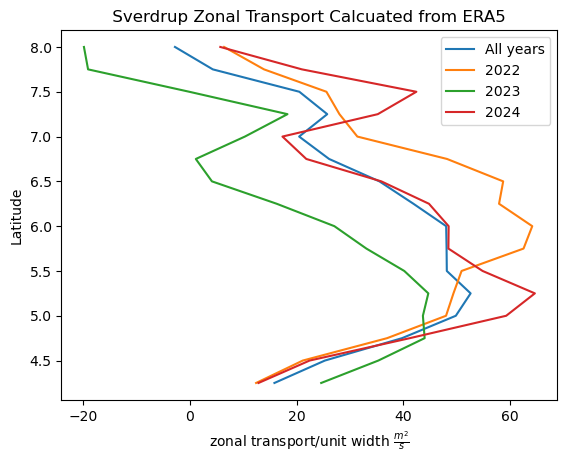

In [303]:
fig, ax = plt.subplots()
ax.plot(    U.mean(axis = 1), windm.lat, label = 'All years')
ax.plot(U2022.mean(axis =1 ), windm.lat,label = 2022)
ax.plot(U2023.mean(axis =1 ), windm.lat,label = 2023)
ax.plot(U2024.mean(axis =1 ), windm.lat,label = 2024)
ax.legend()
ax.set(ylabel = 'Latitude', xlabel = r'zonal transport/unit width $\frac{m^2}{s}$', title = ' Sverdrup Zonal Transport Calcuated from ERA5 ')

Lat: 16 
lon: 15
dy gird (16, 15)
dy gird (16, 15)


C:\Users\czerfass\AppData\Local\Temp\1\ipykernel_18404\1772782408.py:6: UserWarning: The following kwargs were not used by contour: 'c'
  cbr = ax.contourf(X[:,:-1],Y[:,:-1],U, levels = 12, c ='inferno')


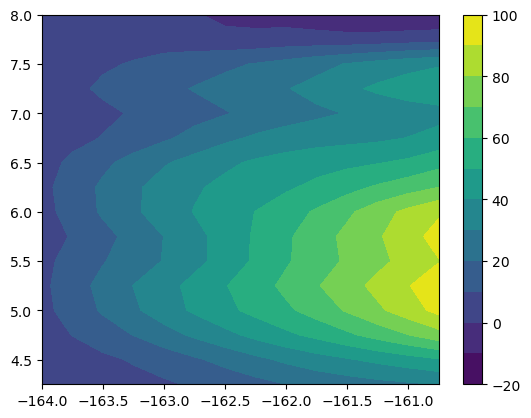

In [304]:
U = Calc_sverdrup(windm)
fig, ax = plt.subplots()
x = windm.lon.values
y = windm.lat.values
X,Y = np.meshgrid(x,y)
cbr = ax.contourf(X[:,:-1],Y[:,:-1],U, levels = 12, c ='inferno')
fig.colorbar(cbr)

In [280]:
U

array([[  1.7109428 ,   3.27168451,   5.21424506,   7.3498743 ,
         10.25634059,  13.41467996,  16.25975663,  19.12624815,
         21.71284   ,  23.55263401,  25.18840207,  26.82058705,
         28.20787753,  30.26115513],
       [  3.41657677,   6.70328   ,  10.11536253,  13.38685815,
         17.19715142,  21.65883385,  26.17657226,  30.50117185,
         34.65890718,  38.19087493,  41.19639504,  44.01845633,
         46.33301021,  49.10966867],
       [  6.29816219,  12.27847377,  18.10140166,  23.46434956,
         28.25122004,  33.33558715,  38.94889709,  44.44624737,
         50.20648977,  55.86150564,  60.87415513,  65.88083697,
         70.82872506,  76.0960685 ],
       [  7.63708596,  14.85685161,  21.89729761,  28.72713777,
         34.84848242,  40.12401032,  45.47168153,  51.38511881,
         57.71687179,  64.67847793,  71.83244955,  78.82810306,
         85.82372784,  92.97097798],
       [  6.19241185,  12.86776002,  19.88048917,  26.57257073,
         33.42702724

In [267]:
def Calc_sverdrup(windm):
    from scipy.sparse.linalg import spsolve
    rho = 1.3 ## density of Air [kg/m^3]
    C_d = 1.25e-3  # wind stress coefient
    rho_w = 1025 # [kg/m^3]
    R = 6371e3 #radius of earth
    omega = 7.29e-5 # [1/s]
    
    latn, lonm = len(windm.lat.values), len(windm.lon.values)

    dx = 0.25
    dy = 0.25
    #Calcuate Tau 
    U_w = np.sqrt(windm.uo**2 + windm.vo**2) ## Chat GPT says to Tau = rho * C_d * U * |U| ???? 
    windm['tau_u'] = rho*C_d*windm.uo*U_w # [N/m^2]
    windm['tau_v'] = rho*C_d*windm.vo*U_w # [N/m^2]

    # take derivative of tau
    Dx,Dxx,Dy,Dyy = build_operators_dirichlet_top(latn,lonm,dx,dy)
    dy_tau_u = Dy@stack2d(windm['tau_u'].values) ## might need to multiply Dy to convert to meters
    dx_tau_v = Dx@stack2d(windm['tau_v'].values)

    curl = dx_tau_v - dy_tau_u
    curl_2d = unstack2d(curl, latn, lonm)
    lat = np.deg2rad(windm.lat.values) # [rad]

    B =  2*omega*np.cos(lat)/R # [1/m/s]
    print(B)
    B_grid = np.repeat(B.reshape(-1,1),lonm, axis = 1)
    psi = curl_2d/(rho_w*B_grid)
    dpsi_dy = Dy@stack2d(psi)

    LG2 = Dx
    psi = spsolve(LG2,dpsi_dy )
    U = unstack2d(psi,latn, lonm )
    return U

U = Calc_sverdrup(windm)

[2.28220180e-11 2.28144008e-11 2.28063491e-11 2.27978633e-11
 2.27889434e-11 2.27795897e-11 2.27698022e-11 2.27595813e-11
 2.27489270e-11 2.27378397e-11 2.27263194e-11 2.27143665e-11
 2.27019811e-11 2.26891635e-11 2.26759140e-11 2.26622327e-11]


In [268]:
def Calc_sverdrup2(ds):

    rho_air = 1.3
    Cd = 1.25e-3
    rho_w = 1025

    U = np.sqrt(ds.uo**2 + ds.vo**2)

    tau_x = rho_air * Cd * U * ds.uo
    tau_y = rho_air * Cd * U * ds.vo

    dx = 111e3 * np.cos(np.deg2rad(ds.lat))
    dy = 111e3

    d_tauy_dx = tau_y.differentiate('lon') / dx
    d_taux_dy = tau_x.differentiate('lat') / dy

    curl = d_tauy_dx - d_taux_dy

    omega = 7.29e-5
    R = 6371e3
    lat = np.deg2rad(ds.lat)

    beta = 2*omega*np.cos(lat)/R

    V = curl/(rho_w*beta)

    return V

In [269]:
def Calc_sverdrup3(ds, return_zonal=True):
    """Compute meridional Sverdrup transport per unit width `V` and optionally
    the zonally-integrated meridional transport `U_zonal`.

    Returns:
      V: DataArray (lat, lon) meridional transport per unit width [m^2/s]
      U_zonal: DataArray (lat,) zonally-integrated meridional transport [m^2/s * m = m^3/s]
              (only returned if `return_zonal` is True).

    Clarification: The classical Sverdrup relation gives meridional transport per unit
    zonal width V = curl/(rho_w * beta) with units m^2/s. Integrating V across longitude
    (multiplying by dx [m] and summing) yields the total meridional transport across the
    basin at each latitude (units m^3/s). This function returns both so you can choose.
    """

    rho_air = 1.3
    Cd = 1.25e-3
    rho_w = 1025.0

    # wind speed magnitude
    Uwind = np.sqrt(ds.uo**2 + ds.vo**2)

    # wind stress components (N/m^2)
    tau_x = rho_air * Cd * Uwind * ds.uo
    tau_y = rho_air * Cd * Uwind * ds.vo

    # derivatives from xarray are in coordinate units (degrees). Convert to per-meter.
    # d(tau_y)/dx: differentiate wrt lon (deg) then divide by meters-per-degree-longitude
    d_tauy_dlon = tau_y.differentiate('lon')
    d_taux_dlat = tau_x.differentiate('lat')

    # meters per degree conversions
    meters_per_deg_lat = 111e3
    meters_per_deg_lon = 111e3 * np.cos(np.deg2rad(ds.lat))

    # convert per-degree derivatives to per-meter derivatives (xarray broadcasting)
    d_tauy_dx = d_tauy_dlon / meters_per_deg_lon
    d_taux_dy = d_taux_dlat / meters_per_deg_lat

    # curl (N/m^3)
    curl = d_tauy_dx - d_taux_dy

    # planetary beta (1/m/s)
    omega = 7.2921159e-5
    
    lat_rad = np.deg2rad(ds.lat)
    beta = 2 * omega * np.cos(lat_rad) / R
    beta_da = xr.DataArray(beta, coords={'lat': ds.lat}, dims=('lat',))

    # meridional transport per unit width V (m^2/s)
    V = curl / (rho_w * beta_da)

    if not return_zonal:
        return V

    # build dx (meters) per grid cell for zonal integration
    lon = ds.lon.values
    delta_lon = np.gradient(lon)  # degrees
    lat_vals = ds.lat.values
    lat_rad_vals = np.deg2rad(lat_vals)

    dx_per_lon = 111e3 * np.cos(lat_rad_vals)[:, None] * np.asarray(delta_lon)[None, :]
    dx_da = xr.DataArray(dx_per_lon, coords={'lat': ds.lat, 'lon': ds.lon}, dims=('lat', 'lon'))

    # zonally-integrated meridional transport (multiply V [m^2/s] by dx [m] -> m^3/s)
    U_zonal = (V * dx_da).sum(dim='lon')

    return V, U_zonal

In [270]:
def Calc_sverdrup4(windm):
    rho_air = 1.3
    rho_w = 1025
    C_d = 1.25e-3
    omega = 7.29e-5
    R = 6371e3

    lat = np.deg2rad(windm.lat)

    # Grid spacing
    dlat = np.deg2rad(np.gradient(windm.lat.values))
    dlon = np.deg2rad(np.gradient(windm.lon.values))

    dy = R * dlat
    dx = R * dlon 
    dlat_lon = np.cos(np.deg2rad(windm.lat.values))
    dy_grid = np.repeat(dy.reshape(-1,1),len(dx), axis = 1)

    dx_grid = (np.repeat(dx.reshape(1,-1),len(dy), axis = 0).T *dlat_lon).T 

    # Wind stress
    U_mag = np.sqrt(windm.uo**2 + windm.vo**2)

    tau_x = rho_air * C_d * windm.uo**2
    tau_y = rho_air * C_d * windm.vo**2

    # Curl
    d_tauy_dx = tau_y.differentiate('lon') / dx_grid
    d_taux_dy = tau_x.differentiate('lat') / dy_grid

    curl = d_tauy_dx - d_taux_dy

    # Beta
    beta = 2 * omega * np.cos(lat) / R

    # Sverdrup transport (integrate from east)
    U = -(1 / (rho_w * beta)) * curl.cumsum(dim='lon') #* dx_grid

    return U
U = Calc_sverdrup(windm)

[2.28220180e-11 2.28144008e-11 2.28063491e-11 2.27978633e-11
 2.27889434e-11 2.27795897e-11 2.27698022e-11 2.27595813e-11
 2.27489270e-11 2.27378397e-11 2.27263194e-11 2.27143665e-11
 2.27019811e-11 2.26891635e-11 2.26759140e-11 2.26622327e-11]
